<a href="https://colab.research.google.com/github/ronitmaheshwari05/final-exam-score-prediction/blob/main/final_exam_score_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
!pip install numpy pandas scikit-learn matplotlib

Model Performance
MSE: 21.33
RMSE: 4.62
R2 Score: 0.83

Feature Importance
                              Coefficient
Attendance (%)                   0.393751
Internal Test 1 (out of 40)      0.891887
Internal Test 2 (out of 40)      0.883050
Assignment Score (out of 10)     1.449677
Daily Study Hours                2.865557

Enter Attendance (%): 92
Enter Internal Test 1 score: 26
Enter Internal Test 2 score: 29
Enter Assignment Score: 9
Enter Daily Study Hours: 5

Predicted Final Exam Marks: 67.58


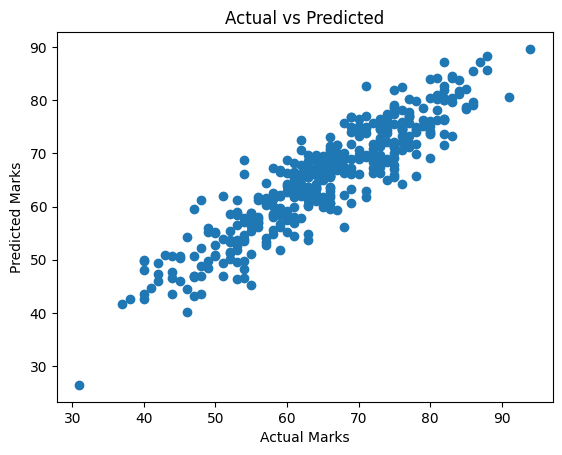

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("Final_Marks_Data.csv")

# Drop unnecessary column
df = df.drop('Student_ID', axis=1)

# Define features and target
X = df[
    [
        'Attendance (%)',
        'Internal Test 1 (out of 40)',
        'Internal Test 2 (out of 40)',
        'Assignment Score (out of 10)',
        'Daily Study Hours'
    ]
]

y = df['Final Exam Marks (out of 100)']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions on test data
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Coefficients (for interpretation)
coeff = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Importance")
print(coeff)

# User input
attendance = float(input("\nEnter Attendance (%): "))
test1 = float(input("Enter Internal Test 1 score: "))
test2 = float(input("Enter Internal Test 2 score: "))
assignment = float(input("Enter Assignment Score: "))
study_hours = float(input("Enter Daily Study Hours: "))

# Convert input to DataFrame
new_data = pd.DataFrame(
    [[attendance, test1, test2, assignment, study_hours]],
    columns=[
        'Attendance (%)',
        'Internal Test 1 (out of 40)',
        'Internal Test 2 (out of 40)',
        'Assignment Score (out of 10)',
        'Daily Study Hours'
    ]
)

# Prediction
predicted_marks = model.predict(new_data)[0]

# Clamp prediction between 0 and 100
predicted_marks = max(0, min(predicted_marks, 100))

print(f"\nPredicted Final Exam Marks: {predicted_marks:.2f}")

# Plot: Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()